In [1]:
!pip install pandas numpy matplotlib seaborn scipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Leer todos los archivos CSV
archivos = [f for f in os.listdir() if f.endswith('.csv')]
print("Archivos encontrados:", archivos)

# Cargar cada archivo
dfs = {}
for archivo in archivos:
    nombre = archivo.replace('.csv', '')
    dfs[nombre] = pd.read_csv(archivo)
    print(f"\n{archivo}: {len(dfs[nombre])} filas")

Archivos encontrados: ['Youtube01-Psy.csv', 'Youtube03-LMFAO.csv', 'Youtube04-Eminem.csv', 'Youtube05-Shakira.csv', 'Youtube02-KatyPerry.csv']

Youtube01-Psy.csv: 350 filas

Youtube03-LMFAO.csv: 438 filas

Youtube04-Eminem.csv: 448 filas

Youtube05-Shakira.csv: 370 filas

Youtube02-KatyPerry.csv: 350 filas


In [5]:
import pandas as pd
import os

# Mapeo de archivos a artistas
mapeo_artistas = {
    'Youtube01-Psy.csv': 'Psy',
    'Youtube02-KatyPerry.csv': 'KatyPerry',
    'Youtube03-LMFAO.csv': 'LMFAO',
    'Youtube04-Eminem.csv': 'Eminem',
    'Youtube05-Shakira.csv': 'Shakira'
}

# Cargar todos los archivos CSV y añadir la columna 'Artista'
dfs = []
for archivo, artista in mapeo_artistas.items():
    if os.path.exists(archivo):
        df_temp = pd.read_csv(archivo)
        df_temp['Artista'] = artista  # Añadir columna Artista
        dfs.append(df_temp)
        print(f"✅ Cargado {archivo}: {len(df_temp)} filas")
    else:
        print(f"❌ Archivo no encontrado: {archivo}")

# Unir todos los DataFrames en uno solo
df_unificado = pd.concat(dfs, ignore_index=True)

print(f"\n✅ DataFrame unificado creado: {len(df_unificado)} filas totales")
print(f"Columnas disponibles: {list(df_unificado.columns)}")

# Verificar que la columna 'Artista' existe
print(f"\nDistribución por artista:")
print(df_unificado['Artista'].value_counts())

✅ Cargado Youtube01-Psy.csv: 350 filas
✅ Cargado Youtube02-KatyPerry.csv: 350 filas
✅ Cargado Youtube03-LMFAO.csv: 438 filas
✅ Cargado Youtube04-Eminem.csv: 448 filas
✅ Cargado Youtube05-Shakira.csv: 370 filas

✅ DataFrame unificado creado: 1956 filas totales
Columnas disponibles: ['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS', 'Artista']

Distribución por artista:
Artista
Eminem       448
LMFAO        438
Shakira      370
Psy          350
KatyPerry    350
Name: count, dtype: int64


ANÁLISIS UNIVARIANTE - VARIABLES CUALITATIVAS

1. DISTRIBUCIÓN DE CLASS (SPAM vs NO SPAM)
--------------------------------------------------
CLASS
1    1005
0     951
Name: count, dtype: int64

Porcentajes:
CLASS
1    51.380368
0    48.619632
Name: proportion, dtype: float64


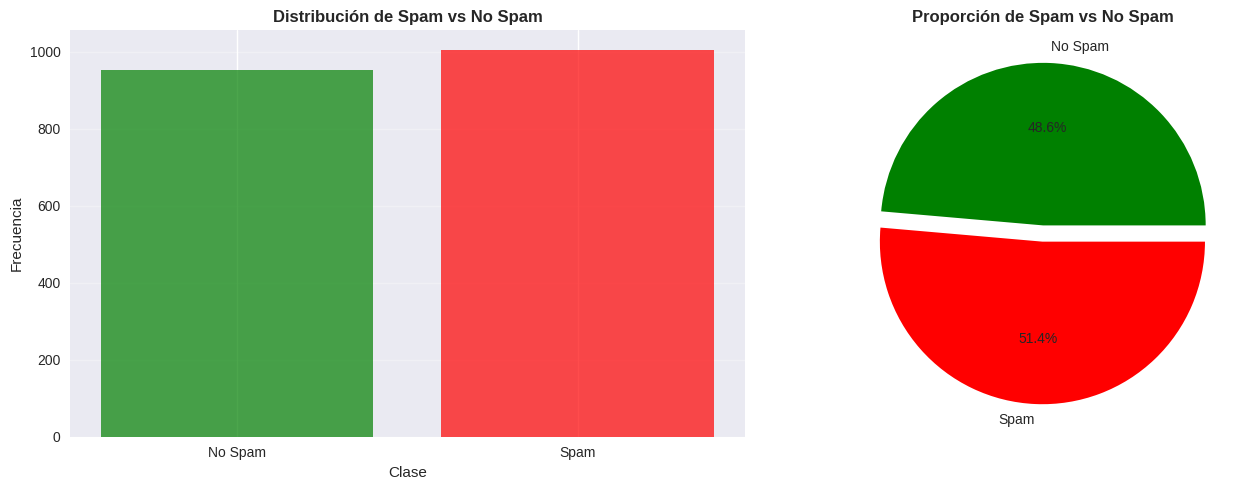


2. DISTRIBUCIÓN POR ARTISTA
--------------------------------------------------
Artista
Eminem       448
LMFAO        438
Shakira      370
Psy          350
KatyPerry    350
Name: count, dtype: int64


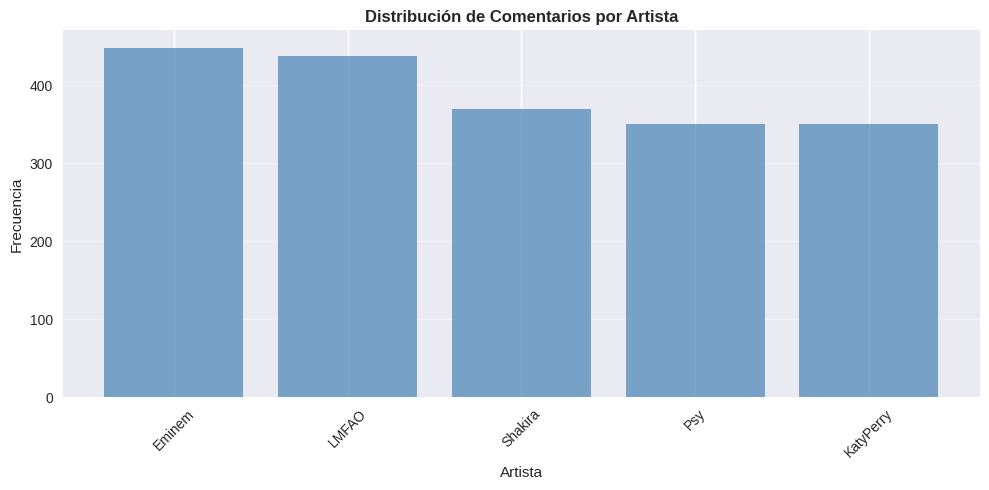


CREANDO VARIABLES CUANTITATIVAS DERIVADAS

✅ Variables creadas:
   - longitud_caracteres
   - longitud_palabras
   - num_mayusculas
   - ratio_mayusculas
   - num_exclamaciones
   - tiene_url

ANÁLISIS UNIVARIANTE - VARIABLES CUANTITATIVAS

VARIABLE: LONGITUD_CARACTERES

Estadísticos Descriptivos:
count    1956.000000
mean       94.703476
std       128.240427
min         2.000000
25%        29.000000
50%        48.000000
75%        97.000000
max      1200.000000
Name: longitud_caracteres, dtype: float64

Asimetría (Skewness): 3.139
Curtosis (Kurtosis): 13.472

Percentiles:
  Percentil 10: 15.00
  Percentil 25: 29.00
  Percentil 50 (Mediana): 48.00
  Percentil 75: 97.00
  Percentil 90: 235.50


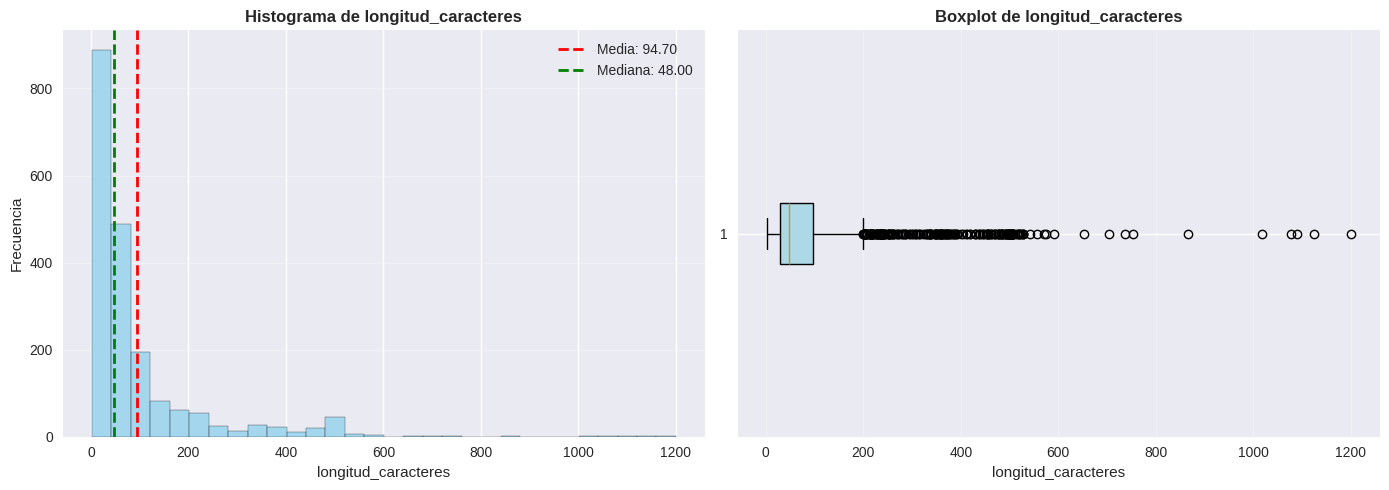


VARIABLE: LONGITUD_PALABRAS

Estadísticos Descriptivos:
count    1956.000000
mean       15.581800
std        21.532844
min         1.000000
25%         5.000000
50%         8.000000
75%        16.000000
max       213.000000
Name: longitud_palabras, dtype: float64

Asimetría (Skewness): 2.949
Curtosis (Kurtosis): 10.679

Percentiles:
  Percentil 10: 2.00
  Percentil 25: 5.00
  Percentil 50 (Mediana): 8.00
  Percentil 75: 16.00
  Percentil 90: 40.00


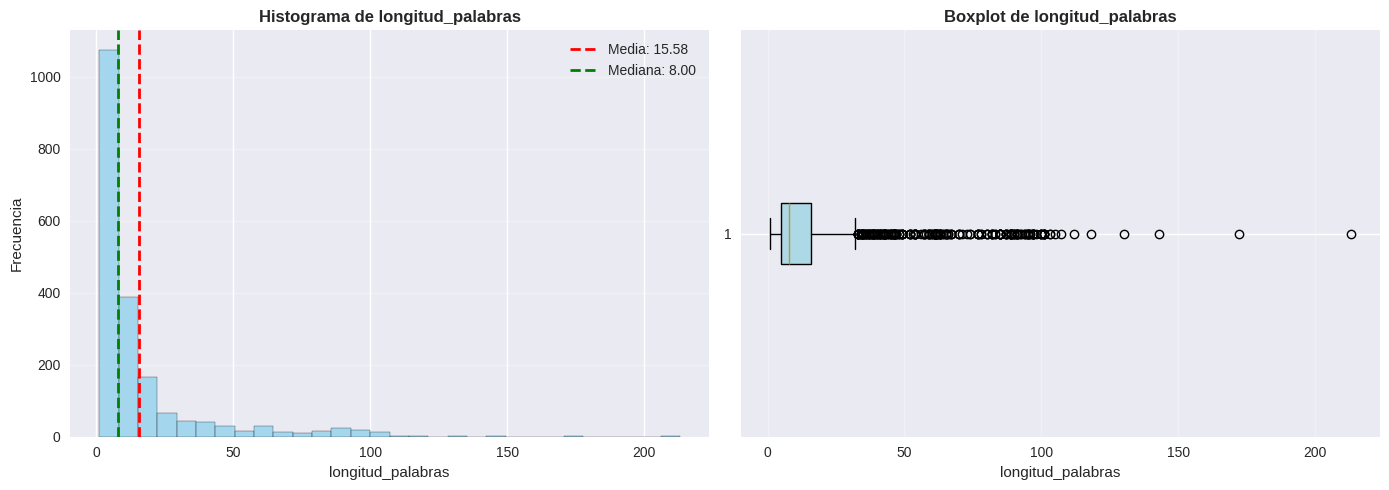


VARIABLE: RATIO_MAYUSCULAS

Estadísticos Descriptivos:
count    1956.000000
mean        0.100448
std         0.168845
min         0.000000
25%         0.015873
50%         0.044362
75%         0.090909
max         1.000000
Name: ratio_mayusculas, dtype: float64

Asimetría (Skewness): 2.993
Curtosis (Kurtosis): 8.793

Percentiles:
  Percentil 10: 0.00
  Percentil 25: 0.02
  Percentil 50 (Mediana): 0.04
  Percentil 75: 0.09
  Percentil 90: 0.23


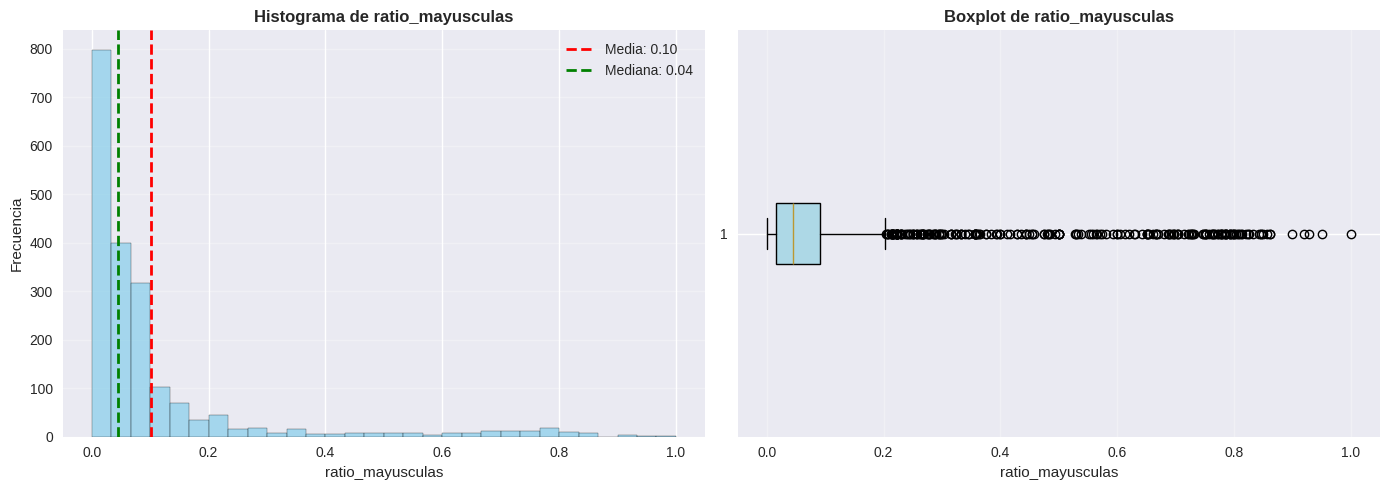


VARIABLE: NUM_EXCLAMACIONES

Estadísticos Descriptivos:
count    1956.000000
mean        1.323620
std        16.734425
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       695.000000
Name: num_exclamaciones, dtype: float64

Asimetría (Skewness): 37.360
Curtosis (Kurtosis): 1517.166

Percentiles:
  Percentil 10: 0.00
  Percentil 25: 0.00
  Percentil 50 (Mediana): 0.00
  Percentil 75: 0.00
  Percentil 90: 3.00


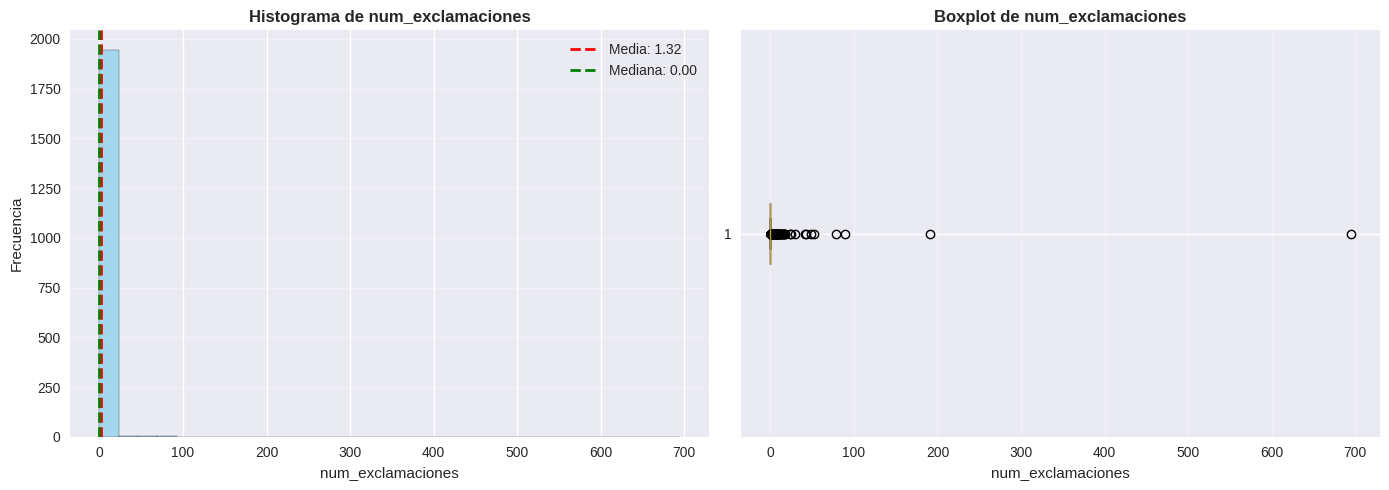


DETECCIÓN DE OUTLIERS (MÉTODO IQR)

longitud_caracteres:
  Límite inferior: -73.00
  Límite superior: 199.00
  Outliers detectados: 245 (12.53%)

longitud_palabras:
  Límite inferior: -11.50
  Límite superior: 32.50
  Outliers detectados: 241 (12.32%)

ratio_mayusculas:
  Límite inferior: -0.10
  Límite superior: 0.20
  Outliers detectados: 220 (11.25%)

num_exclamaciones:
  Límite inferior: 0.00
  Límite superior: 0.00
  Outliers detectados: 463 (23.67%)

✅ ANÁLISIS UNIVARIANTE COMPLETADO


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# ANÁLISIS UNIVARIANTE - VARIABLES CUALITATIVAS
# =============================================================================

print("="*70)
print("ANÁLISIS UNIVARIANTE - VARIABLES CUALITATIVAS")
print("="*70)

# 1. VARIABLE: CLASS (Spam vs No Spam)
print("\n1. DISTRIBUCIÓN DE CLASS (SPAM vs NO SPAM)")
print("-" * 50)
tabla_class = df_unificado['CLASS'].value_counts()
print(tabla_class)
print(f"\nPorcentajes:")
print(df_unificado['CLASS'].value_counts(normalize=True) * 100)

# Gráfico de barras para CLASS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['No Spam', 'Spam'],
            [tabla_class.get(0, 0), tabla_class.get(1, 1)],
            color=['green', 'red'], alpha=0.7)
axes[0].set_title('Distribución de Spam vs No Spam', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de tarta
axes[1].pie([tabla_class.get(0, 0), tabla_class.get(1, 1)],
            labels=['No Spam', 'Spam'],
            autopct='%1.1f%%',
            colors=['green', 'red'],
            explode=(0.05, 0.05))
axes[1].set_title('Proporción de Spam vs No Spam', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_class.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. VARIABLE: ARTISTA
print("\n2. DISTRIBUCIÓN POR ARTISTA")
print("-" * 50)
tabla_artista = df_unificado['Artista'].value_counts()
print(tabla_artista)

# Gráfico de barras para Artista
plt.figure(figsize=(10, 5))
plt.bar(tabla_artista.index, tabla_artista.values, color='steelblue', alpha=0.7)
plt.title('Distribución de Comentarios por Artista', fontsize=12, fontweight='bold')
plt.xlabel('Artista')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('grafico_artista.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# CREAR VARIABLES CUANTITATIVAS DERIVADAS DEL CONTENIDO
# =============================================================================

print("\n" + "="*70)
print("CREANDO VARIABLES CUANTITATIVAS DERIVADAS")
print("="*70)

# Longitud del comentario en caracteres
df_unificado['longitud_caracteres'] = df_unificado['CONTENT'].str.len()

# Longitud en palabras
df_unificado['longitud_palabras'] = df_unificado['CONTENT'].str.split().str.len()

# Número de mayúsculas
df_unificado['num_mayusculas'] = df_unificado['CONTENT'].str.count(r'[A-Z]')

# Ratio de mayúsculas
df_unificado['ratio_mayusculas'] = df_unificado['num_mayusculas'] / df_unificado['longitud_caracteres']
df_unificado['ratio_mayusculas'] = df_unificado['ratio_mayusculas'].fillna(0)

# Número de signos de exclamación
df_unificado['num_exclamaciones'] = df_unificado['CONTENT'].str.count(r'!')

# Número de URLs
df_unificado['tiene_url'] = df_unificado['CONTENT'].str.contains(r'http|www', case=False, na=False).astype(int)

print("\n✅ Variables creadas:")
print("   - longitud_caracteres")
print("   - longitud_palabras")
print("   - num_mayusculas")
print("   - ratio_mayusculas")
print("   - num_exclamaciones")
print("   - tiene_url")

# =============================================================================
# ANÁLISIS UNIVARIANTE - VARIABLES CUANTITATIVAS
# =============================================================================

print("\n" + "="*70)
print("ANÁLISIS UNIVARIANTE - VARIABLES CUANTITATIVAS")
print("="*70)

vars_cuantitativas = ['longitud_caracteres', 'longitud_palabras', 'ratio_mayusculas', 'num_exclamaciones']

for var in vars_cuantitativas:
    print(f"\n{'='*70}")
    print(f"VARIABLE: {var.upper()}")
    print('='*70)

    # Estadísticos descriptivos
    print("\nEstadísticos Descriptivos:")
    print(df_unificado[var].describe())

    # Asimetría y curtosis
    print(f"\nAsimetría (Skewness): {stats.skew(df_unificado[var].dropna()):.3f}")
    print(f"Curtosis (Kurtosis): {stats.kurtosis(df_unificado[var].dropna()):.3f}")

    # Percentiles
    print(f"\nPercentiles:")
    print(f"  Percentil 10: {df_unificado[var].quantile(0.10):.2f}")
    print(f"  Percentil 25: {df_unificado[var].quantile(0.25):.2f}")
    print(f"  Percentil 50 (Mediana): {df_unificado[var].quantile(0.50):.2f}")
    print(f"  Percentil 75: {df_unificado[var].quantile(0.75):.2f}")
    print(f"  Percentil 90: {df_unificado[var].quantile(0.90):.2f}")

    # Histograma
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df_unificado[var].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0].axvline(df_unificado[var].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df_unificado[var].mean():.2f}')
    axes[0].axvline(df_unificado[var].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df_unificado[var].median():.2f}')
    axes[0].set_title(f'Histograma de {var}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Boxplot
    axes[1].boxplot(df_unificado[var].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[1].set_title(f'Boxplot de {var}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(var)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'histograma_boxplot_{var}.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# DETECCIÓN DE OUTLIERS
# =============================================================================

print("\n" + "="*70)
print("DETECCIÓN DE OUTLIERS (MÉTODO IQR)")
print("="*70)

for var in vars_cuantitativas:
    Q1 = df_unificado[var].quantile(0.25)
    Q3 = df_unificado[var].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_unificado[(df_unificado[var] < limite_inferior) |
                            (df_unificado[var] > limite_superior)]

    print(f"\n{var}:")
    print(f"  Límite inferior: {limite_inferior:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(df_unificado)*100:.2f}%)")

print("\n" + "="*70)
print("✅ ANÁLISIS UNIVARIANTE COMPLETADO")
print("="*70)